In [1]:
import numpy as np
import EFC_learningfMRI.globals as gl
from EFC_learningfMRI.util import get_trained_and_untrained
from EFC_learningfMRI.vis import plot_im_sess
import os
import pandas as pd
import PcmPy as pcm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


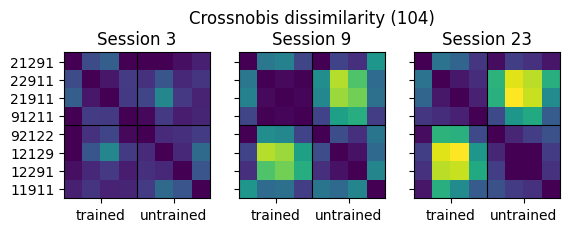

In [2]:
sn = 104
H = 'L'
roi = 'SMA'
G = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs.{H}.{roi}.npy'))
D = pcm.G_to_dist(G)

trained_untrained = get_trained_and_untrained(sn)

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True,)

vmin, vmax = 0, D.max()

for i in range(D.shape[0]):
    ax = axs[i]
    im = ax.imshow(D[i], vmin=vmin, vmax=vmax)
    ax.set_title(f'Crossnobis dissimilarity ({sn})\nSession {gl.sessions[i]}') if i==1 else ax.set_title(f'Session {gl.sessions[i]}')
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)

Text(0.5, 0, 'session')

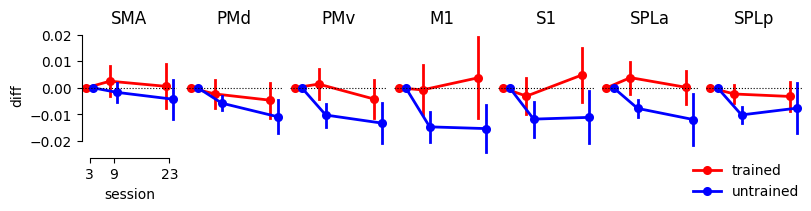

In [3]:
rois          = gl.rois['ROI']
diss_pred = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity_prediction.ROI.glm3.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

hue_order = ['trained', 'untrained']
palette = ['red', 'blue']

plot_im_sess(fig, axs, diss_pred, rois, y='diff', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3, add_zero=True)
#plot_im_sess(fig, axs, diss_pred, rois, y='diff', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)
sb.despine(ax=axs[0], trim=True)
#axs[0].set_ylabel('activation (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')


Text(0.5, 0, 'session')

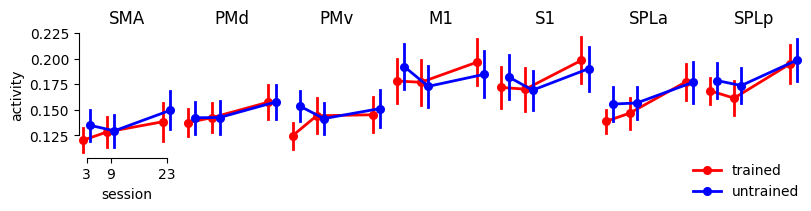

In [4]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

hue_order = ['trained', 'untrained']
palette = ['red', 'blue']

plot_im_sess(fig, axs, diss_pred, rois, y='activity', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3, add_zero=False)
#plot_im_sess(fig, axs, diss_pred, rois, y='diff', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)
sb.despine(ax=axs[0], trim=True)
#axs[0].set_ylabel('activation (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

Text(0.5, 0, 'session')

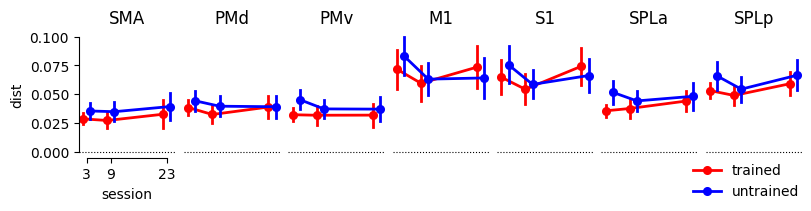

In [5]:
rois          = gl.rois['ROI']
diss = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity.ROI.glm3.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

hue_order = ['trained', 'untrained']
palette = ['red', 'blue']

plot_im_sess(fig, axs, diss, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3, add_zero=True)
#plot_im_sess(fig, axs, diss_pred, rois, y='diff', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)
sb.despine(ax=axs[0], trim=True)
#axs[0].set_ylabel('activation (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

Text(0.5, 0, 'session')

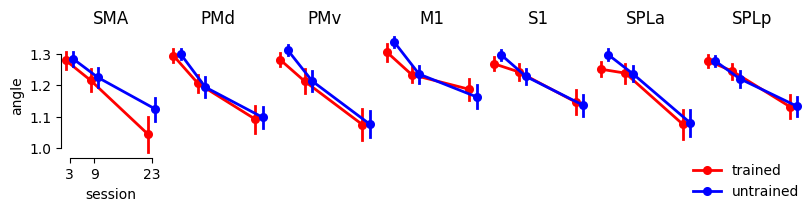

In [6]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

hue_order = ['trained', 'untrained']
palette = ['red', 'blue']

plot_im_sess(fig, axs, diss, rois, y='angle', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3,)
#plot_im_sess(fig, axs, diss_pred, rois, y='diff', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)
sb.despine(ax=axs[0], trim=True)
#axs[0].set_ylabel('activation (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')